In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid')

import jax
import numpyro

from cntmosaic.sim import load_base_patterns, load_age_distribution, simulate_ses
from cntmosaic.preprocess import make_train_data
from cntmosaic.models import HiBRCFine
from cntmosaic.visuals import plot_cint_matrix, plot_cint_marginal

In [2]:
# Specify the path to the mixing-patterns repository
repo_path = '/Users/shozendan/Imperial/0_Research/mixing-patterns'

# print_available_countries(repo_path)
country = 'United_States'
level = 'country'

patterns = load_base_patterns(repo_path, country, level, symmetrise=True, smooth=True)
age_dist = load_age_distribution(repo_path, country, level)

In [3]:
df_sample, age_dist_props, df_eval = simulate_ses(patterns, age_dist.P.values, dist='poisson')

# Convert the SES to an ordered categorical variable
df_sample['ses'] = pd.Categorical(df_sample['ses'], categories=['low', 'mid', 'high'], ordered=True)

# Make the training data
df_train = make_train_data(df_sample, id_var='id', grp_vars=['ses'])

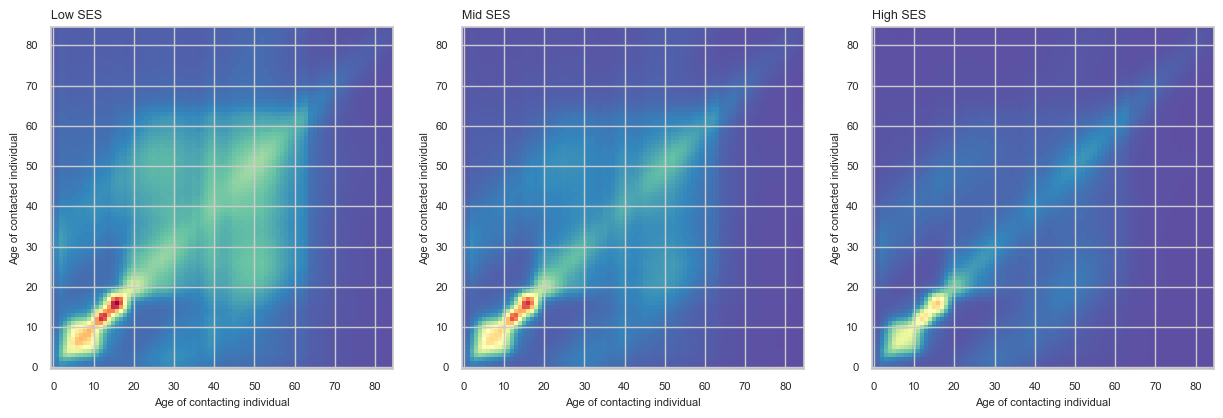

In [ ]:
from cntmosaic.visuals import plot_cint_matrix, plot_cint_marginal

cint_low = df_eval[df_eval['ses'] == 'low']['cint'].values.reshape(85, 85)
cint_mid = df_eval[df_eval['ses'] == 'mid']['cint'].values.reshape(85, 85)
cint_high = df_eval[df_eval['ses'] == 'high']['cint'].values.reshape(85, 85)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

vmin = df_eval['cint'].values.min()
vmax = df_eval['cint'].values.max()

plot_cint_matrix(ax[0], cint_low, title='Low SES', vmin=vmin, vmax=vmax)
plot_cint_matrix(ax[1], cint_mid, title='Mid SES', vmin=vmin, vmax=vmax)
plot_cint_matrix(ax[2], cint_high, title='High SES', vmin=vmin, vmax=vmax)

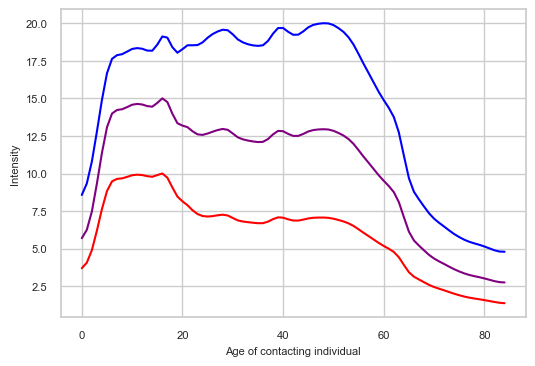

In [43]:
mcint_low = cint_low.sum(axis=-1)
mcint_mid = cint_mid.sum(axis=-1)
mcint_high = cint_high.sum(axis=-1)

fig, ax = plt.subplots(figsize=(6,4))

plot_cint_marginal(ax, mcint_low, color='blue')
plot_cint_marginal(ax, mcint_mid, color='purple')
plot_cint_marginal(ax, mcint_high, color='red')

In [4]:
model = HiBRCFine(df_train, age_dist.P.values, age_dist_props)
model.print_model_shape()

             Trace Shapes:          
              Param Sites:          
             Sample Sites:          
             baseline dist         |
                     value         |
             gp_scale dist         |
                     value         |
          gp_lenscale dist         |
                     value         |
     hsgp_basis_coef plate     900 |
                 beta dist     900 |
                     value     900 |
               ses/x plate       2 |
         ses/tspline plate     841 |
ses/tspline_intercept dist 2     1 |
                     value 2     1 |
     ses/tspline_coef dist 2   841 |
                     value 2   841 |
       inv_dispersion dist         |
                     value         |
                  obs dist   21675 |
                     value   21675 |


In [5]:
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.initialization import init_to_value

init_values = {
  'baseline': -model.log_P.mean(),
  'hsgp_scale': 0.1,
  'hsgp_lengthscale': 1.0
}

prng_key = jax.random.PRNGKey(0)
guide = AutoNormal(model.model, init_loc_fn=init_to_value(values=init_values))
model.run_inference_svi(prng_key, guide)

100%|██████████| 5000/5000 [01:08<00:00, 72.53it/s, init loss: 177038.3906, avg. loss [4751-5000]: 29375.5690]


In [6]:
po_svi = model.posterior_predictive_svi(prng_key, guide)

In [7]:
po_log_delta = po_svi['ses/log_delta'].mean(axis=0)
po_delta = np.exp(po_log_delta)

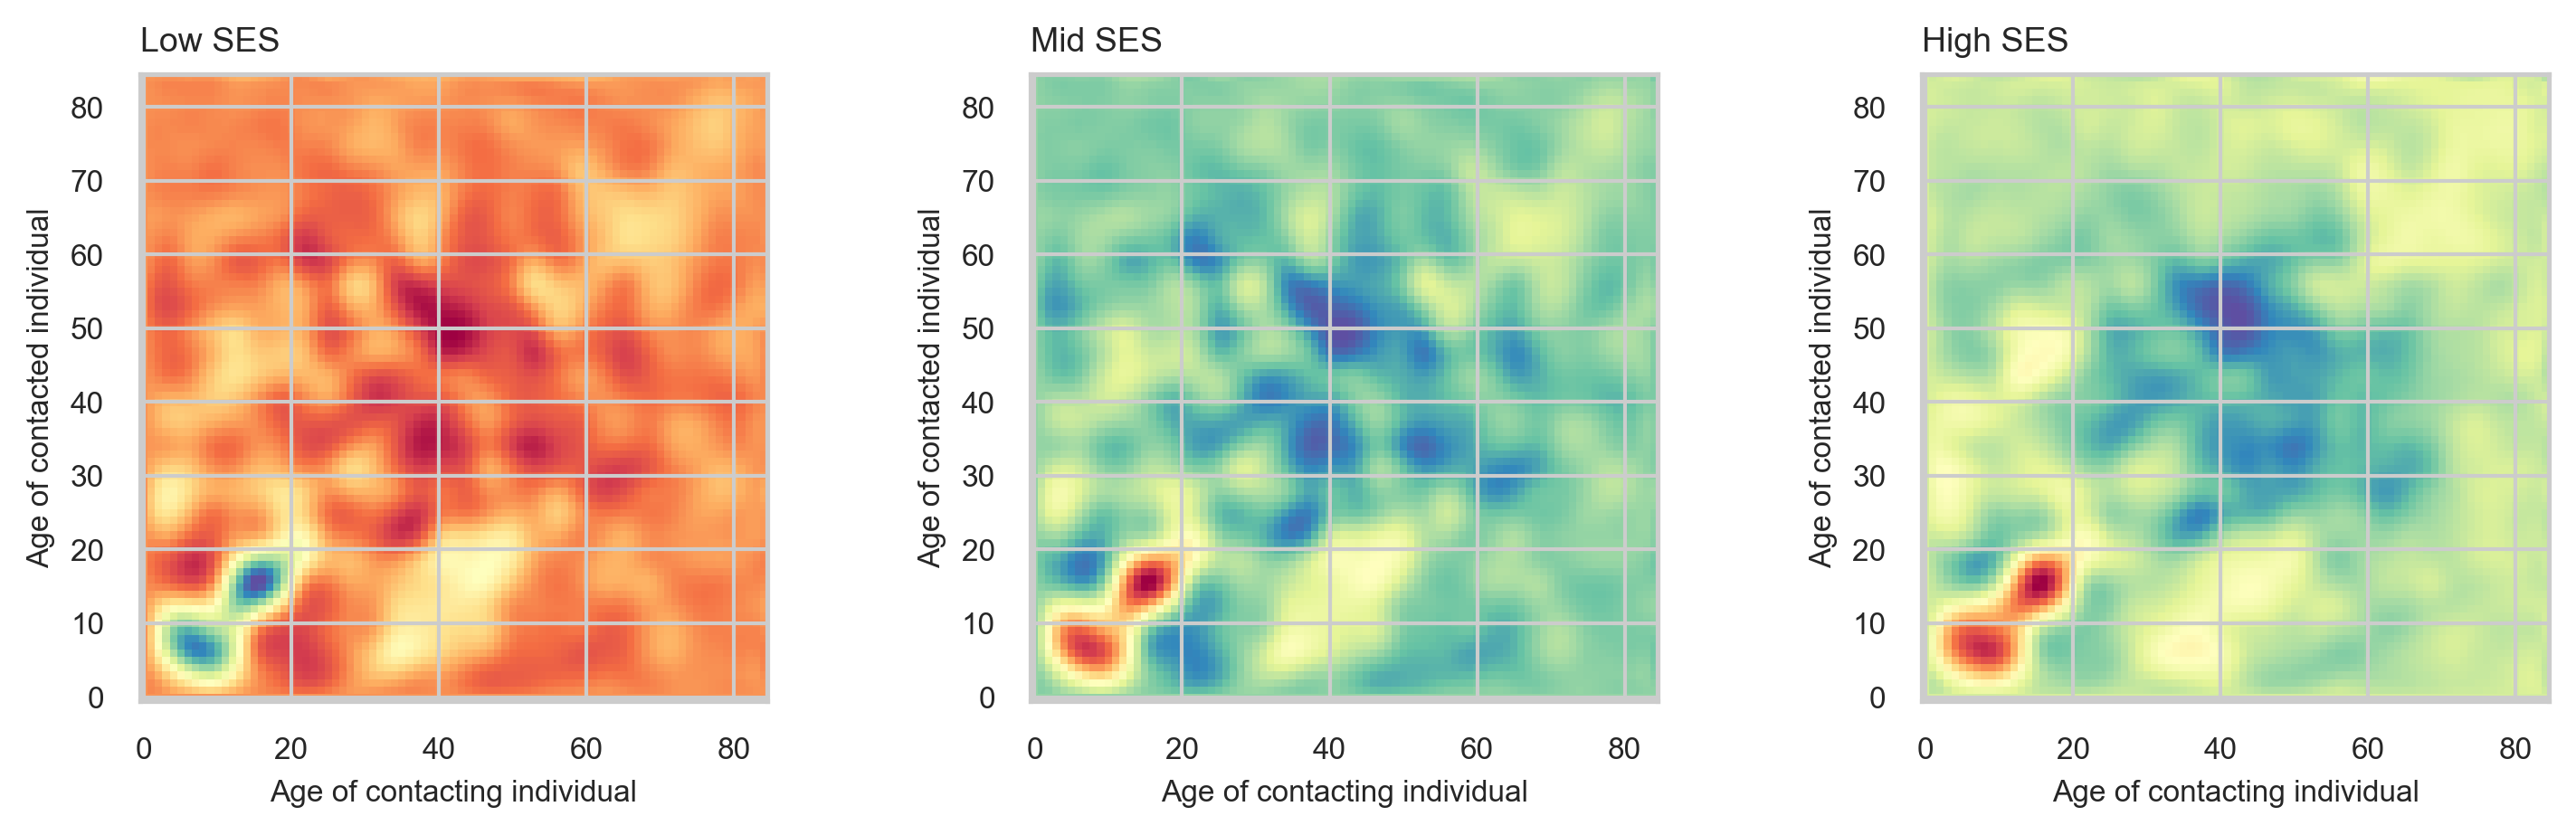

In [12]:
from cntmosaic.visuals import plot_cint_matrix

fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=300)

plot_cint_matrix(ax[0], po_delta[0,:,:], title='Low SES')
plot_cint_matrix(ax[1], po_delta[1,:,:], title='Mid SES')
plot_cint_matrix(ax[2], po_delta[2,:,:], title='High SES')

In [ ]:
log_rate = po_svi['log_rate']
log_delta = po_svi['ses/log_delta']
log_rate = log_rate[:,None,:,:] + log_delta

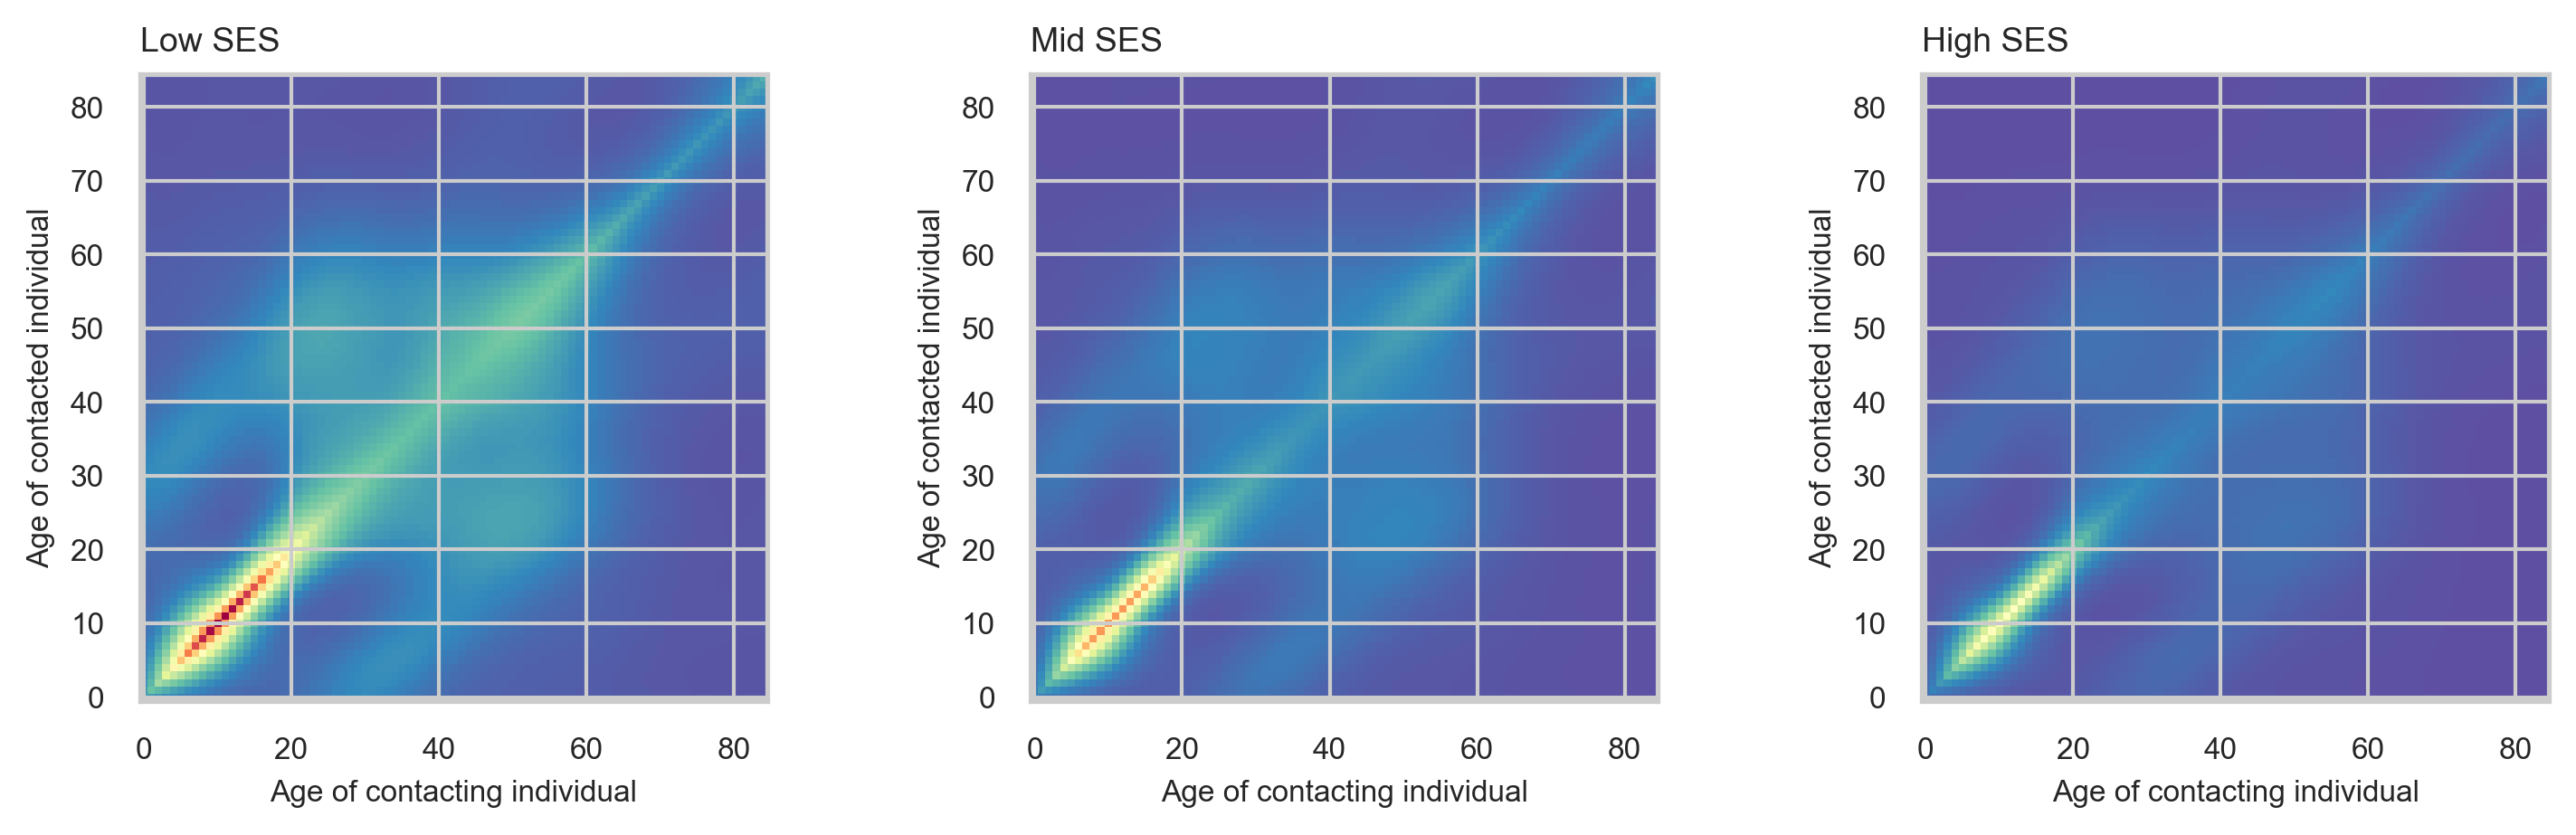

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=300)

rate_mean = np.exp(log_rate.mean(axis=0))
vmin = rate_mean.min()
vmax = rate_mean.max()
plot_cint_matrix(ax[0], rate_mean[0,:,:], title='Low SES', vmin=vmin, vmax=vmax)
plot_cint_matrix(ax[1], rate_mean[1,:,:], title='Mid SES', vmin=vmin, vmax=vmax)
plot_cint_matrix(ax[2], rate_mean[2,:,:], title='High SES', vmin=vmin, vmax=vmax)

In [25]:
log_cint = log_rate + model.log_P[None,None,:,:]

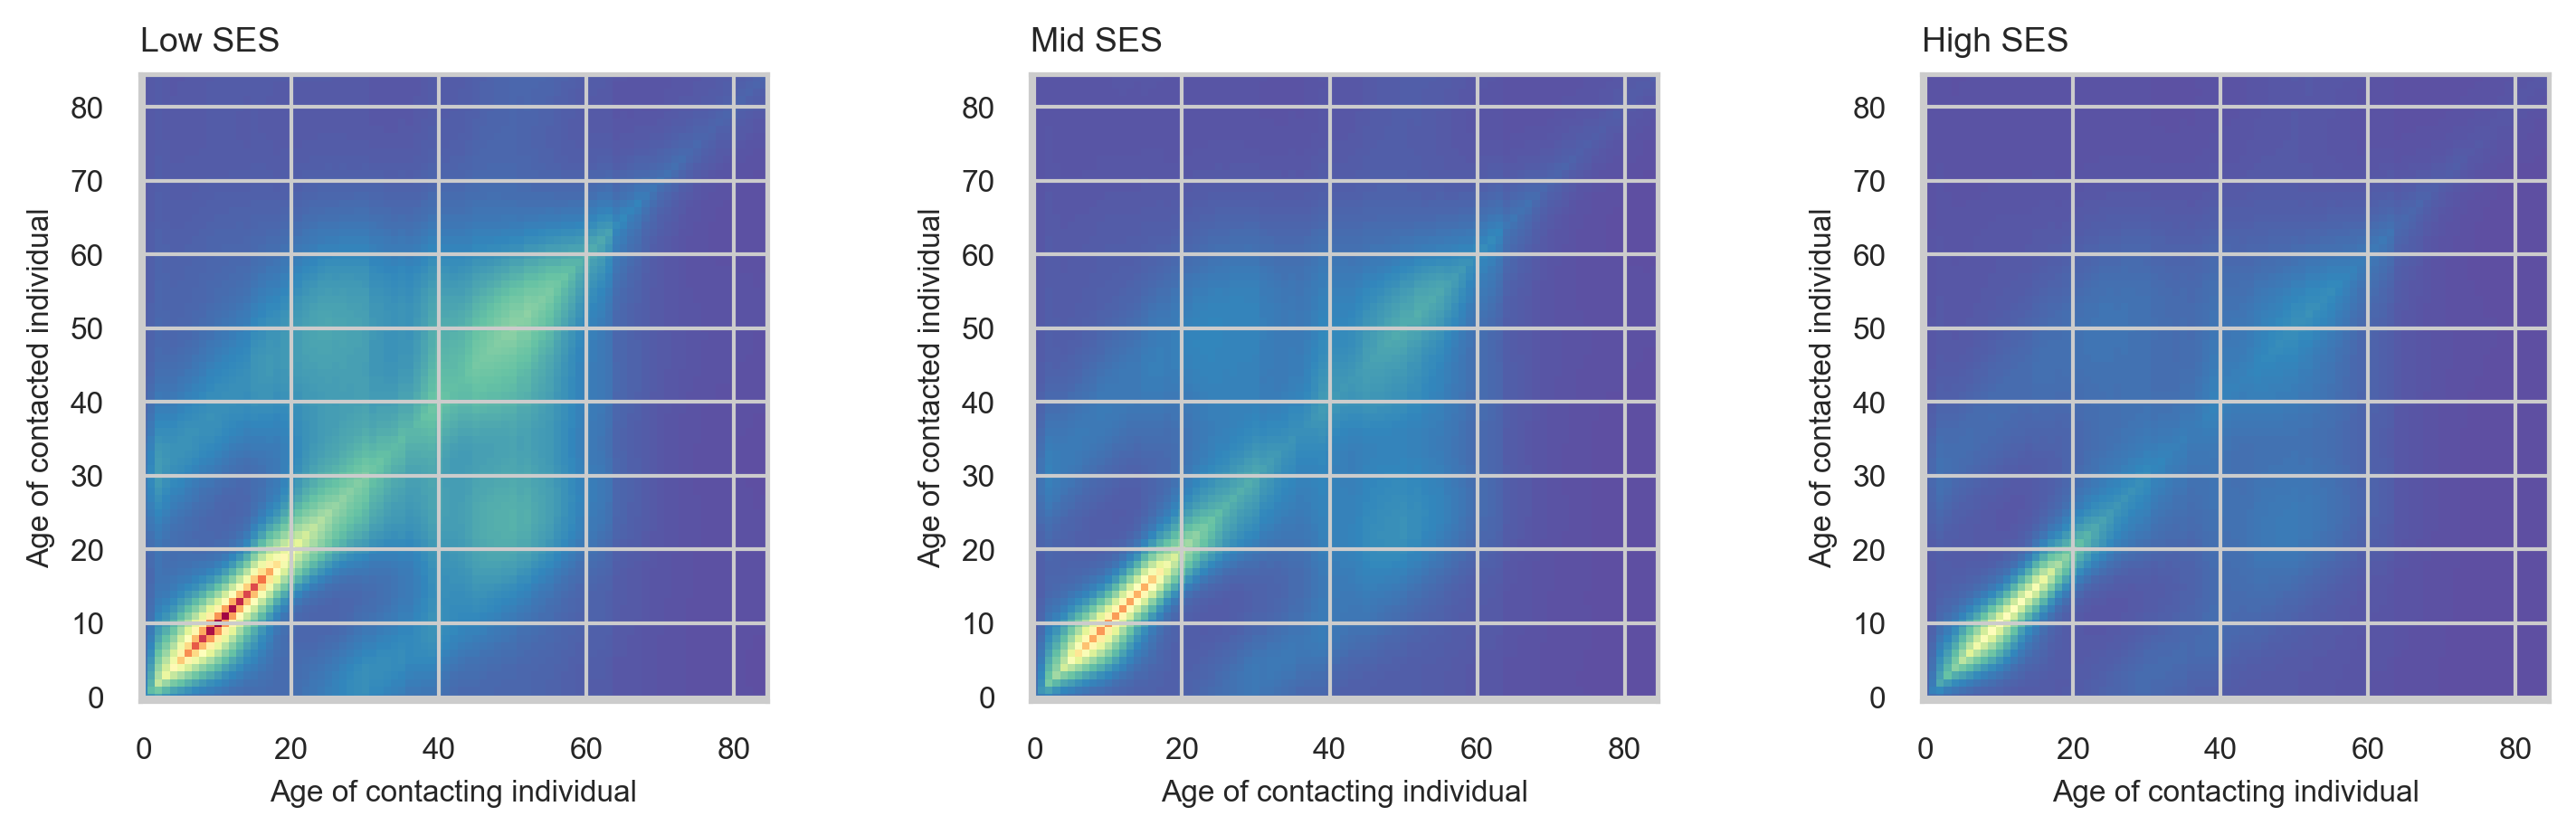

In [26]:
cint_mean = np.exp(log_cint.mean(axis=0))

fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=300)

vmin = cint_mean.min()
vmax = cint_mean.max()

plot_cint_matrix(ax[0], cint_mean[0,:,:], title='Low SES', vmin=vmin, vmax=vmax)
plot_cint_matrix(ax[1], cint_mean[1,:,:], title='Mid SES', vmin=vmin, vmax=vmax)
plot_cint_matrix(ax[2], cint_mean[2,:,:], title='High SES', vmin=vmin, vmax=vmax)

plt.show()

In [29]:
cint = np.exp(log_cint)
mcint = cint.sum(axis=-1)
mcint = mcint.mean(axis=0)

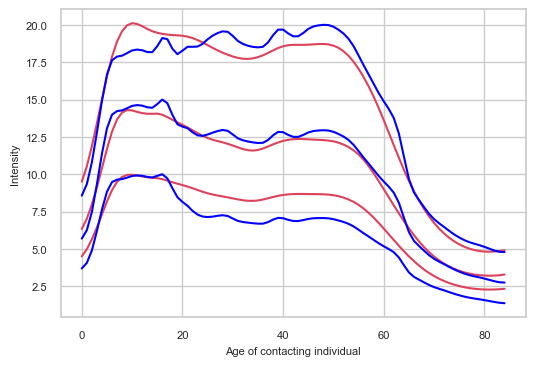

In [46]:
from cntmosaic.visuals import plot_cint_marginal

fig, ax = plt.subplots(figsize=(6, 4), dpi=100)

plot_cint_marginal(ax, mcint[0,:])
plot_cint_marginal(ax, mcint_low, color='blue')
plot_cint_marginal(ax, mcint[1,:])
plot_cint_marginal(ax, mcint_mid, color='blue')
plot_cint_marginal(ax, mcint[2,:])
plot_cint_marginal(ax, mcint_high, color='blue')